PART A – DATA ANALYSIS



Step 1: Import Libraries

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

Step 2: Load Dataset

In [ ]:
df = pd.read_csv("loan_prediction.csv")

Step 3: Data Understanding

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Step 4: Dataset Profiling

In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


Step 5: Missing Value

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


Fill Categorical Missing Values

In [ ]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

Fill Numerical Missing Values

In [ ]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Step 6: Duplicate Handling

In [ ]:
df.duplicated().sum()

np.int64(0)

Step 7: Remove Unnecessary Column

In [ ]:
df.drop('Loan_ID', axis=1, inplace=True)

Step 8: Outlier Analysis

In [ ]:
num_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
]

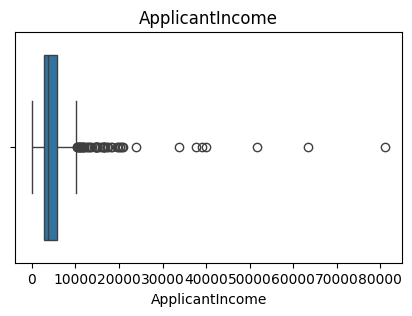

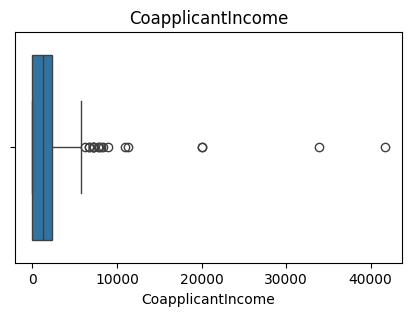

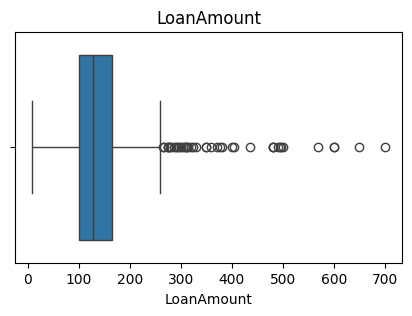

In [ ]:
for col in num_cols:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Interpretation

Income and LoanAmount generally contain outliers.

Boxplot analysis revealed outliers in ApplicantIncome, CoapplicantIncome, and LoanAmount. These values may represent genuine high-income applicants and large loan requests rather than data entry errors. Therefore, outliers were retained for model development

Step 9: Feature Engineering

In [20]:
df['TotalIncome'] = (
    df['ApplicantIncome'] +
    df['CoapplicantIncome']
)

Banks evaluate combined household income.

It better represents repayment capacity than individual incomes.

Visualization


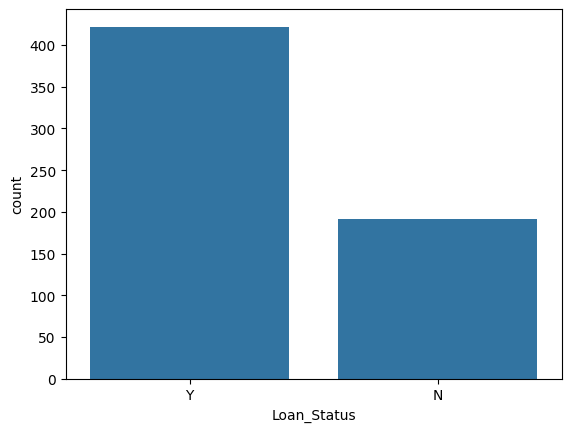

In [23]:

# Loan Status Distribution


sns.countplot(
    x='Loan_Status',
    data=df
)

plt.show()

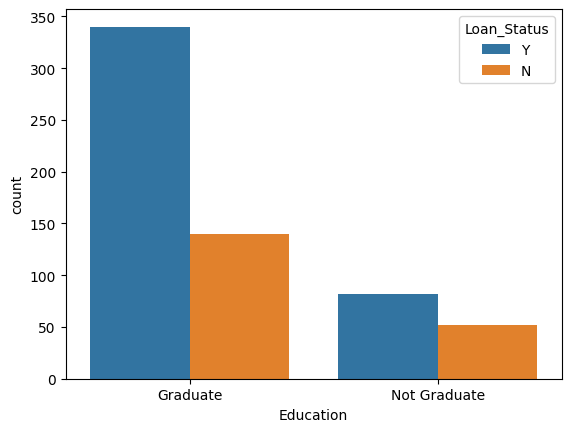

In [24]:
# Education vs Loan Status

sns.countplot(
    x='Education',
    hue='Loan_Status',
    data=df
)

plt.show()

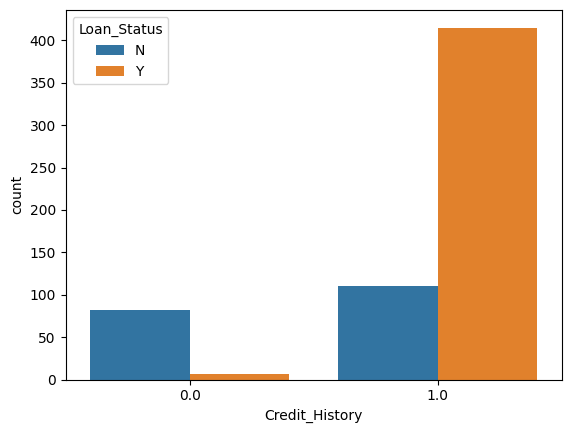

In [25]:
# Credit History vs Loan Status


sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df
)

plt.show()

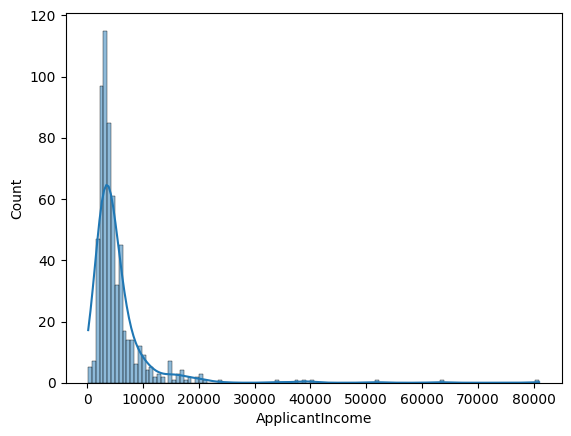

In [27]:
# Applicant Income Distribution

sns.histplot(
    df['ApplicantIncome'],
    kde=True
)

plt.show()

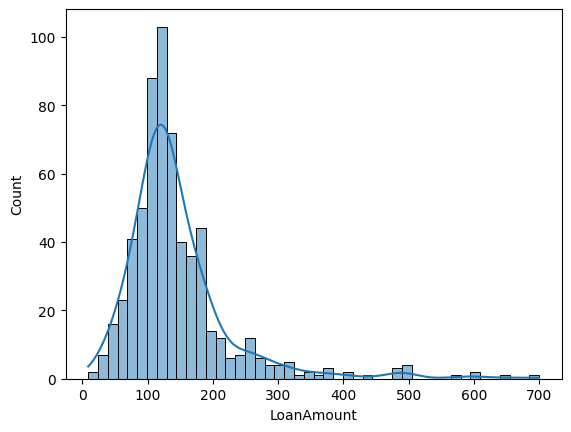

In [28]:
# Loan Amount Distribution


sns.histplot(
    df['LoanAmount'],
    kde=True
)

plt.show()

Step 11: Encoding

In [29]:
le = LabelEncoder()

In [30]:
for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(df[col])

Step 12: Correlation Analysis

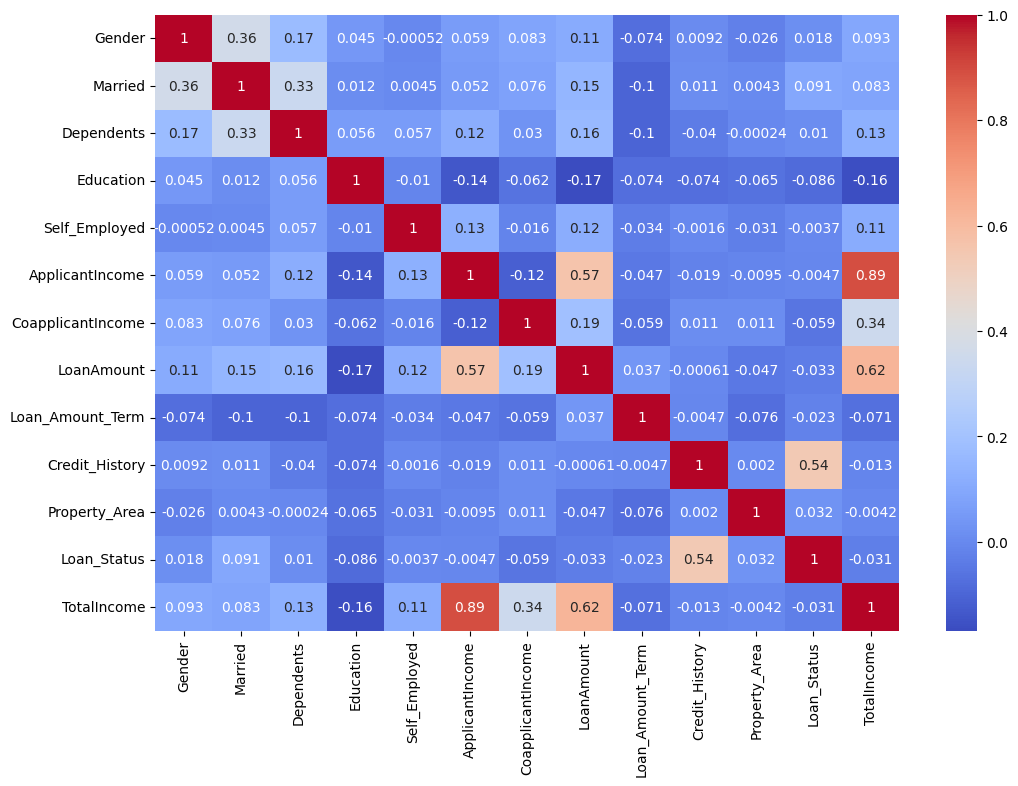

In [31]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

Credit_History has the strongest positive relationship with loan approval. Applicants with good credit history are much more likely to receive loan approval.

Correlation Analysis :
1 .Credit_History showed the strongest correlation with Loan_Status (0.54).
2. ApplicantIncome and TotalIncome exhibited strong correlation (0.89).
3. LoanAmount showed moderate correlation with TotalIncome (0.62).
4. Demographic variables such as Gender and Dependents showed very weak relationships with loan approval.
5. Credit history appears to be the most influential factor in loan approval decisions.

# Part A Conclusion

1 .Missing values were present and treated.
2. No significant duplicate records found.
3. Income and loan amount contained outliers.
4. TotalIncome feature was created.
5. Credit_History appears strongly related to loan approval.
6. Correlation analysis suggests Credit_History and income-related features influence loan decisions.

Interpretation

Applicants with strong credit history are significantly more likely to receive loan approval. Income alone is not sufficient; credit behavior plays a more important role in approval decisions.

614 rows
Mixed categorical + numerical features
Non-linear relationships

PART B – MODEL DEVELOPMENT

Step 1: Feature Selection

In [32]:
y = df['Loan_Status']

X = df.drop('Loan_Status', axis=1)

Step 2: Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Step 3: Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [35]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
# Prediction:

y_pred_lr = lr.predict(X_test)

In [37]:
lr_acc = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8617886178861789


Step 4: Decision Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [40]:
y_pred_dt = dt.predict(X_test)

In [41]:
dt_acc = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7154471544715447


Step 5: Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
y_pred_rf = rf.predict(X_test)

In [46]:
rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8211382113821138


Step 6: Compare Models

In [104]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.861789
1        Decision Tree  0.715447
2        Random Forest  0.821138


Step 9: Final Evaluation

In [105]:
train_acc_lr = lr.score(X_train, y_train)

test_acc_lr = lr.score(X_test, y_test)

print("Train:", train_acc_lr)
print("Test:", test_acc_lr)

Train: 0.7983706720977597
Test: 0.8617886178861789


Part B Conclusion


Three classification algorithms were evaluated: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression achieved the highest testing accuracy of 86.18%, outperforming Random Forest (82.11%) and Decision Tree (71.54%). The model also demonstrated good generalization performance with no significant evidence of overfitting. Therefore, Logistic Regression was selected as the final model.

Classification Report

In [110]:
from sklearn.metrics import classification_report


In [108]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [109]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[22 16]
 [ 1 84]]


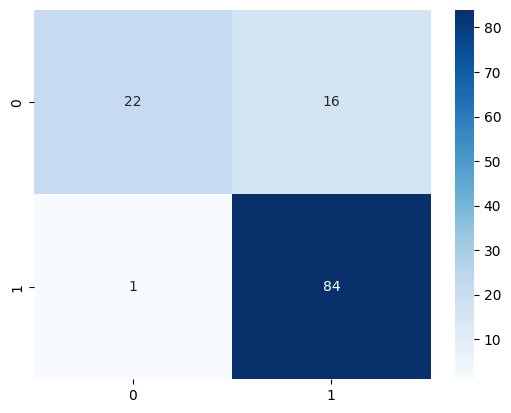

In [107]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

Accuracy is good, but the model incorrectly approves 16 risky applicants. Since false approvals can create financial loss, additional risk checks should be included before deployment.

PART C
1. What Business Problem Was Solved?

A predictive model was developed to identify whether a loan applicant is likely to receive loan approval based on demographic, financial, and credit-related information. This helps reduce financial risk while supporting customer acquisition.

2. Which Variables Influenced the Outcome Most?

Based on correlation analysis and business understanding:

Most Important
Credit_History

Other Important Variables
LoanAmount
TotalIncome
ApplicantIncome
Property_Area

3. What Insights Were Discovered?
Insight 1

Applicants with good credit history are significantly more likely to receive loan approval.

Insight 2

Income alone does not strongly influence approval decisions.

Insight 3

Loan amount and total household income play moderate roles.

Insight 4

Demographic variables such as gender have little impact.

4. What Risks Exist in Deployment?
Risk 1

False approvals.

16 risky applicants

were approved.

This can create financial loss.


Risk 2

Future applicant behavior may differ from historical data.

Risk 3

Economic conditions may change.

5. Final Recommendation to Management
Use the model as a decision-support system.
Give highest importance to Credit_History.
Perform additional verification for borderline applicants.
Continuously retrain the model with new loan data.
Combine model predictions with human review for high-value loans.

Problem Type:
Binary Classification

Models Evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best Model:
Logistic Regression

Training Accuracy:
79.84%

Testing Accuracy:
86.18%

Reason:
Highest testing accuracy and good generalization performance.